In [2]:
## Decision Tree Regressor
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
from sklearn.datasets import load_diabetes
df = load_diabetes(as_frame=True).frame

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [5]:
df.shape

(442, 11)

### Task : Predict the target

In [6]:
# Feature selelction
X = df.drop('target', axis=1)
y = df['target']

In [7]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [9]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE Train :", mean_squared_error(y_train, y_pred_train))
print("MSE Test :", mean_squared_error(y_test, y_pred_test))

print("r2 Score Train :", r2_score(y_train, y_pred_train))
print("r2 Score Test :", r2_score(y_test, y_pred_test))


MSE Train : 0.0
MSE Test : 4469.797752808989
r2 Score Train : 1.0
r2 Score Test : 0.15634772936421437


[Text(0.6141050852597032, 0.975, 'bmi <= 0.005\nsquared_error = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.359120189171559, 0.925, 's5 <= 0.006\nsquared_error = 3612.73\nsamples = 209\nvalue = 118.043'),
 Text(0.4866126372156311, 0.95, 'True  '),
 Text(0.1903538812785388, 0.875, 's5 <= -0.043\nsquared_error = 2378.339\nsamples = 152\nvalue = 100.559'),
 Text(0.08170254403131115, 0.825, 's1 <= -0.039\nsquared_error = 1425.414\nsamples = 49\nvalue = 80.878'),
 Text(0.05251141552511415, 0.775, 's1 <= -0.046\nsquared_error = 1663.902\nsamples = 28\nvalue = 94.75'),
 Text(0.02674494455316373, 0.725, 's6 <= -0.076\nsquared_error = 1058.16\nsamples = 24\nvalue = 84.083'),
 Text(0.005218525766470972, 0.675, 's1 <= -0.082\nsquared_error = 723.5\nsamples = 4\nvalue = 113.0'),
 Text(0.002609262883235486, 0.625, 'squared_error = 0.0\nsamples = 1\nvalue = 70.0'),
 Text(0.007827788649706457, 0.625, 's1 <= -0.074\nsquared_error = 142.889\nsamples = 3\nvalue = 127.333'),
 Text(0.0052185257664

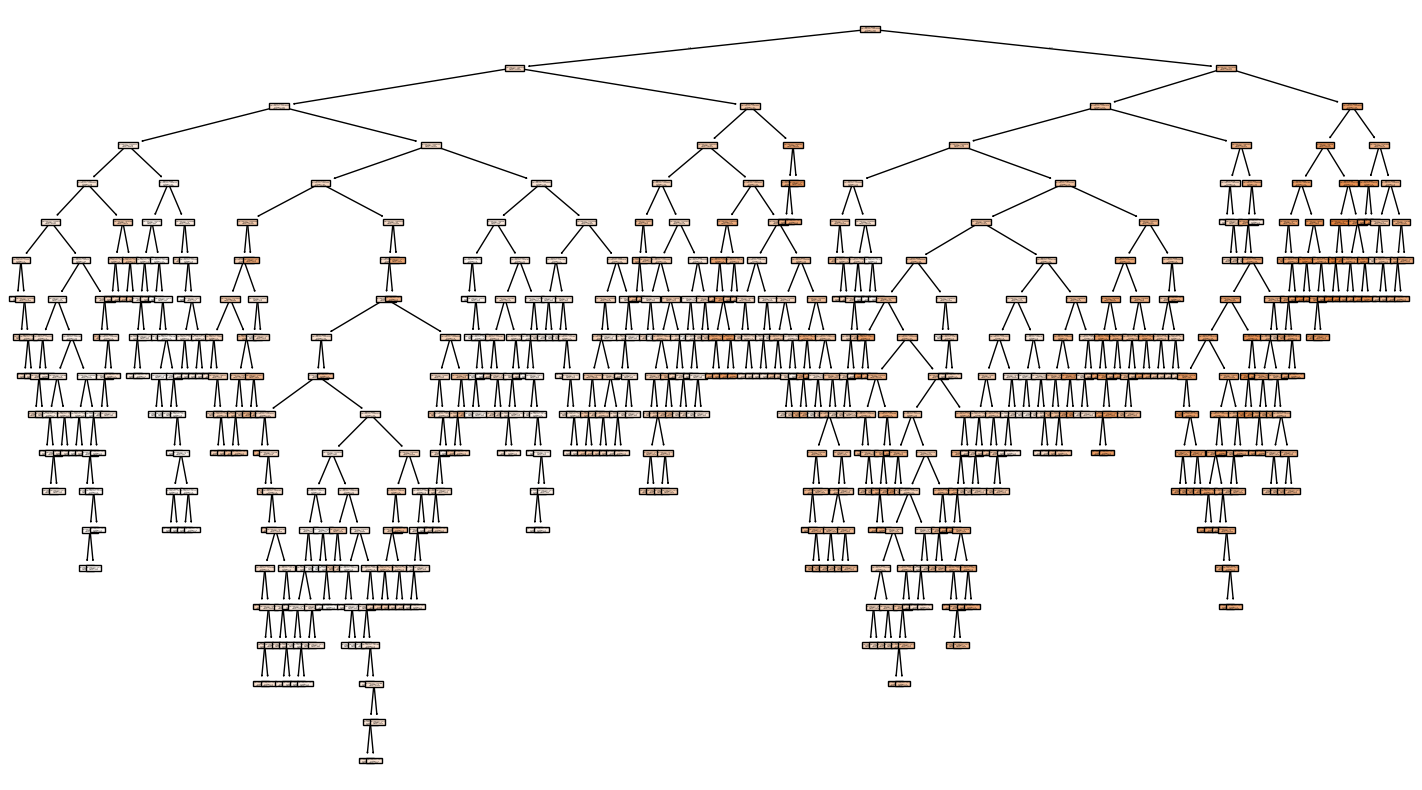

In [10]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

In [11]:
# Pre Pruning
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=7, min_samples_leaf=20)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [12]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("MSE Train :", mean_squared_error(y_train, y_pred_train))
print("MSE Test :", mean_squared_error(y_test, y_pred_test))

print("r2 Score Train :", r2_score(y_train, y_pred_train))
print("r2 Score Test :", r2_score(y_test, y_pred_test))


MSE Train : 2712.48075111857
MSE Test : 3258.996155814711
r2 Score Train : 0.5536038381089772
r2 Score Test : 0.38488055637002505


[Text(0.640625, 0.9285714285714286, 'bmi <= 0.005\nsquared_error = 6076.398\nsamples = 353\nvalue = 153.737'),
 Text(0.40625, 0.7857142857142857, 's5 <= 0.006\nsquared_error = 3612.73\nsamples = 209\nvalue = 118.043'),
 Text(0.5234375, 0.8571428571428572, 'True  '),
 Text(0.25, 0.6428571428571429, 's5 <= -0.043\nsquared_error = 2378.339\nsamples = 152\nvalue = 100.559'),
 Text(0.125, 0.5, 's1 <= -0.039\nsquared_error = 1425.414\nsamples = 49\nvalue = 80.878'),
 Text(0.0625, 0.35714285714285715, 'squared_error = 1663.902\nsamples = 28\nvalue = 94.75'),
 Text(0.1875, 0.35714285714285715, 'squared_error = 508.712\nsamples = 21\nvalue = 62.381'),
 Text(0.375, 0.5, 's3 <= 0.025\nsquared_error = 2559.722\nsamples = 103\nvalue = 109.922'),
 Text(0.3125, 0.35714285714285715, 's3 <= -0.016\nsquared_error = 3012.59\nsamples = 64\nvalue = 121.859'),
 Text(0.25, 0.21428571428571427, 'squared_error = 3221.835\nsamples = 22\nvalue = 137.727'),
 Text(0.375, 0.21428571428571427, 'bmi <= -0.025\nsquare

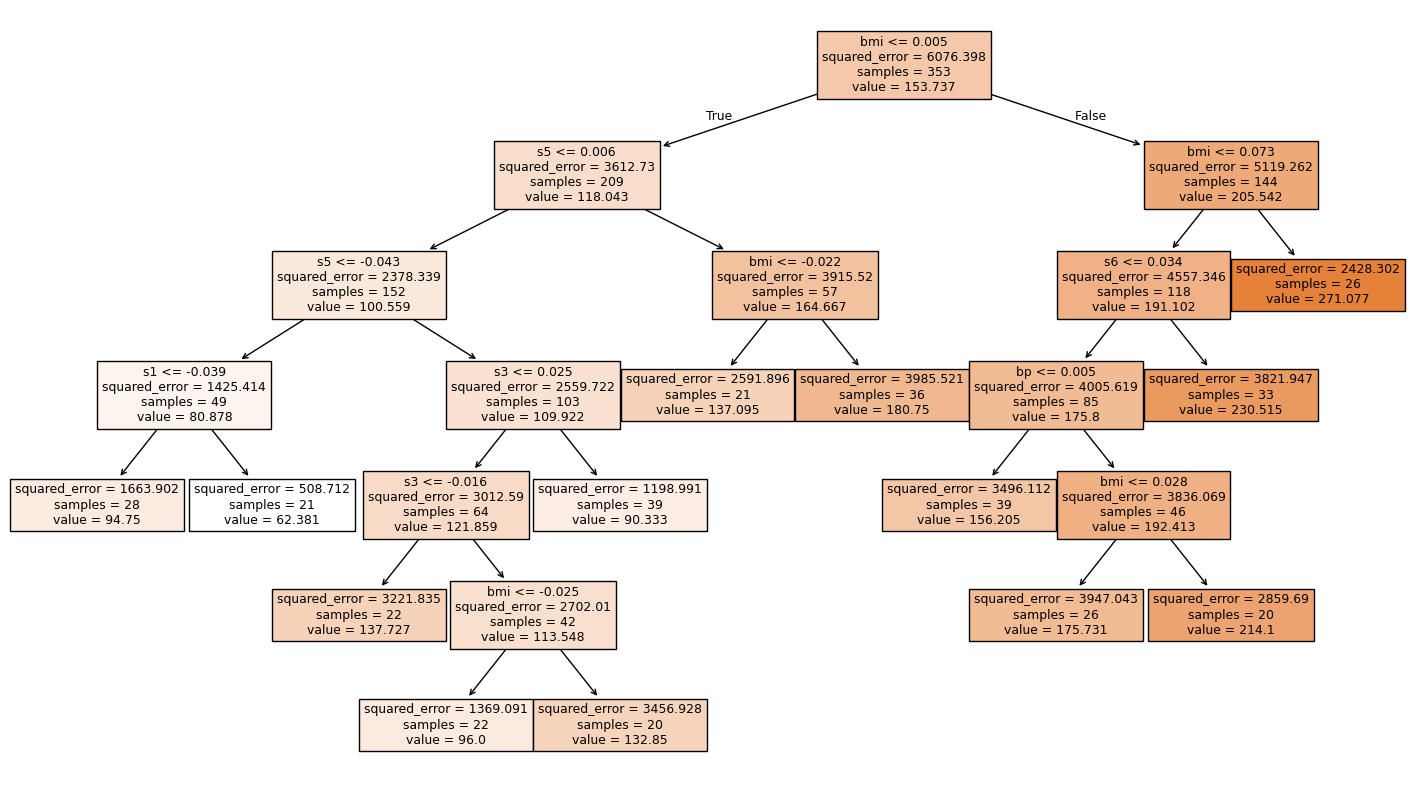

In [13]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
rf = RandomForestRegressor(
    oob_score=True,
    max_depth=4,
    n_estimators=801
)

rf.fit(X_train, y_train)

d:\Anaconda\Lib\site-packages\sklearn\ensemble\_forest.py:513: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y)


,n_estimators,801
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [22]:
y_pred = rf.predict(X_test)

In [24]:
print("MSE :", mean_squared_error(y_test, y_pred))
print("r 2 :", r2_score(y_test, y_pred))
print("OBB Score :", rf.oob_score_)

MSE : 2811.062328798447
r 2 : 0.469425855991101
OBB Score : 0.44691853629963507
